In [7]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. 初期パラメータ設定 (Experiment Configurations)
# =====================================================================
# [モデル設定]
N = 40                  # 変数の数 (観測の数 P も今回は同じ40)
F = 10.0                # 強制項
dt = 0.01               # 積分時間ステップ
sampling_dt = 0.05      # 観測・同化の間隔 (6時間相当: 0.25日/5日)
m = 8                   # アンサンブルメンバー数
p = 40                  # 観測点の数 (今回は全点観測なので N と同じ)

# [時間設定]
years = 2
units_per_year = 73.0   # 1年 = 365日 / 5日 = 73ユニット
total_time = years * units_per_year
spin_up_time = units_per_year

steps_total = int(total_time / dt)
steps_spin_up = int(spin_up_time / dt)
sampling_interval = int(sampling_dt / dt)

# [データ同化設定]
H_mat = np.eye(N)                       # 観測演算子 H (全点観測)
R_mat = np.eye(N)                       # 観測誤差共分散 R (対角成分1)

# =====================================================================
# 2. Nature Run (真値) と Observation (観測) の生成
# =====================================================================
def lorenz96(x, F):
    return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F

def M(x_in, dt, steps):
    x_out = x_in.copy()
    for _ in range(steps):
        k1 = lorenz96(x_out, F)
        k2 = lorenz96(x_out + k1 * (dt / 2.0), F)
        k3 = lorenz96(x_out + k2 * (dt / 2.0), F)
        k4 = lorenz96(x_out + k3 * dt, F)
        x_out += (k1 + 2.0*k2 + 2.0*k3 + k4) * (dt / 6.0)
    return x_out

print("Nature Runと観測データを生成中...")
x = np.full(N, F)
x[19] += 1.001

true_states = []
for s in range(steps_total):
    x = M(x, dt, 1)
    if s >= steps_spin_up and (s - steps_spin_up) % sampling_interval == 0:
        true_states.append(x.copy())
true_states = np.array(true_states)

rng_obs = np.random.default_rng(seed=67) 
noise = rng_obs.normal(loc=0.0, scale=1.0, size=true_states.shape)
noise -= np.mean(noise, axis=0)
y_o_data_full = true_states + noise

num_cycles = y_o_data_full.shape[0]

print("生成完了！")

Nature Runと観測データを生成中...
生成完了！


In [8]:
# =====================================================================
# 3. LETKF + RTPP / RTPS 完成版
# =====================================================================


def symmetric_sqrt(A, eig_floor=1.0e-12):
    """
    対称行列 A の対称平方根 A^{1/2} を返す。
    数値誤差で非有限値や分解失敗が出た場合は、
    対称化と微小ジッターを入れてフォールバックする。
    """
    A = np.asarray(A, dtype=float)
    A = 0.5 * (A + A.T)
    A = np.nan_to_num(A, nan=0.0, posinf=0.0, neginf=0.0)
    A = A + eig_floor * np.eye(A.shape[0])

    try:
        eigvals, eigvecs = np.linalg.eigh(A)
        eigvals = np.maximum(eigvals, eig_floor)
        return eigvecs @ np.diag(np.sqrt(eigvals)) @ eigvecs.T
    except np.linalg.LinAlgError:
        u, s, vt = np.linalg.svd(A, full_matrices=False)
        s = np.maximum(s, eig_floor)
        return u @ np.diag(np.sqrt(s)) @ vt



def make_H(obs_indices, N):
    """
    観測点 obs_indices に対応する線形観測演算子 H を作る。
    全点観測なら obs_indices = np.arange(N)。
    """
    obs_indices = np.asarray(obs_indices, dtype=int)
    H = np.zeros((len(obs_indices), N))
    for k, j in enumerate(obs_indices):
        H[k, j] = 1.0
    return H



def gaspari_like_weight(distance, sigma):
    """
    元のノートの R_localization_inv に合わせた簡易ガウス型局所化。
    距離がしきい値より大きい観測は重み0。
    """
    cutoff = np.sqrt(10.0 / 3.0) * sigma * 2.0
    if distance < cutoff:
        return np.exp(-(distance**2) / (2.0 * sigma**2))
    return 0.0



def localization_weights_for_grid(i, obs_indices, sigma, N):
    """
    状態変数 i の解析に使う観測局所化重みを返す。
    戻り値 shape: (p_obs,)
    """
    weights = np.zeros(len(obs_indices))
    for k, j in enumerate(obs_indices):
        d = min(abs(i - j), N - abs(i - j))
        weights[k] = gaspari_like_weight(d, sigma)
    return weights



def letkf_analysis(
    X_b,
    y_o,
    H,
    R,
    obs_indices,
    sigma,
    inflation=1.0,
    method="none",
    alpha=0.0,
    eps=1.0e-12,
):
    """
    1同化サイクル分の LETKF 解析を行う。

    method:
        "none" : 通常LETKF
        "rtpp" : RTPP LETKF
        "rtps" : RTPS LETKF

    使用する主な式:

    xb_mean = mean(X_b)
    dX_b    = X_b - xb_mean

    yb_mean = mean(H X_b)
    dY_b    = H X_b - yb_mean
    innov   = y_o - yb_mean

    P_a_tilde =
        [ (m-1)/Delta I + dY_b^T R^{-1}_loc dY_b ]^{-1}

    w =
        P_a_tilde dY_b^T R^{-1}_loc innov

    xa_mean_i =
        xb_mean_i + dX_b_i w

    W =
        [ (m-1) P_a_tilde ]^{1/2}

    dXa_base_i =
        dX_b_i W

    RTPP:
        dXa_i = (1-alpha) dXa_base_i + alpha sqrt(Delta) dX_b_i

    RTPS:
        r_i = 1 - alpha + alpha sqrt(Delta) sigma_b_i / sigma_a_i
        dXa_i = r_i dXa_base_i
    """
    N, m = X_b.shape
    obs_indices = np.asarray(obs_indices, dtype=int)

    # 1. background mean and perturbation
    xb_mean = np.mean(X_b, axis=1)              # shape: (N,)
    dX_b = X_b - xb_mean[:, None]              # shape: (N, m)

    # 2. observation ensemble
    Y_b_ens = H @ X_b                           # shape: (p_obs, m)
    yb_mean = np.mean(Y_b_ens, axis=1)          # shape: (p_obs,)
    dY_b = Y_b_ens - yb_mean[:, None]           # shape: (p_obs, m)

    # 3. innovation
    innovation = y_o - yb_mean                  # shape: (p_obs,)

    # 4. output arrays
    X_a = np.zeros_like(X_b)
    xa_mean = np.zeros(N)
    dXa = np.zeros_like(X_b)

    R_diag = np.diag(R)

    for i in range(N):
        # 5. local R^{-1}
        loc_weights = localization_weights_for_grid(i, obs_indices, sigma, N)
        Rloc_inv_diag = loc_weights / R_diag

        # 6. P_a_tilde
        # P_a_tilde = [ (m-1)/Delta I + dY_b^T Rloc^{-1} dY_b ]^{-1}
        Rinv_dY = Rloc_inv_diag[:, None] * dY_b
        A = ((m - 1) / inflation) * np.eye(m) + dY_b.T @ Rinv_dY
        A = 0.5 * (A + A.T)
        A = np.nan_to_num(A, nan=0.0, posinf=0.0, neginf=0.0)
        P_a_tilde = np.linalg.pinv(A, rcond=1.0e-12)
        P_a_tilde = 0.5 * (P_a_tilde + P_a_tilde.T)

        # 7. mean weight
        # w = P_a_tilde dY_b^T Rloc^{-1} innovation
        Rinv_innov = Rloc_inv_diag * innovation
        w = P_a_tilde @ dY_b.T @ Rinv_innov

        # 8. analysis mean
        # xa_mean_i = xb_mean_i + dX_b_i w
        xa_mean[i] = xb_mean[i] + dX_b[i, :] @ w

        # 9. transform matrix
        # W = [ (m-1) P_a_tilde ]^{1/2}
        W = symmetric_sqrt((m - 1) * P_a_tilde)

        # 10. base analysis perturbation
        # dXa_base_i = dX_b_i W
        dXa_base_i = dX_b[i, :] @ W

        # 11. inflation method
        if method == "none":
            dXa_i = dXa_base_i

        elif method == "rtpp":
            # dXa_RTPP = (1-alpha)dXa + alpha sqrt(Delta)dXb
            dXb_inf_i = np.sqrt(inflation) * dX_b[i, :]
            dXa_i = (1.0 - alpha) * dXa_base_i + alpha * dXb_inf_i

        elif method == "rtps":
            # sigma_b_i = std(dXb_i), sigma_a_i = std(dXa_i)
            sigma_b_i = np.std(dX_b[i, :], ddof=1)
            sigma_a_i = np.std(dXa_base_i, ddof=1)

            # r_i = 1-alpha + alpha sqrt(Delta) sigma_b_i / sigma_a_i
            rtps_factor_i = (
                1.0 - alpha
                + alpha * np.sqrt(inflation) * sigma_b_i / (sigma_a_i + eps)
            )
            dXa_i = rtps_factor_i * dXa_base_i

        else:
            raise ValueError("method must be 'none', 'rtpp', or 'rtps'.")

        # 12. perturbation mean should be zero
        dXa_i = dXa_i - np.mean(dXa_i)

        dXa[i, :] = dXa_i
        X_a[i, :] = xa_mean[i] + dXa_i

    return X_a, xa_mean, dXa


def run_letkf_experiment(
    y_o_data,
    true_states,
    obs_indices=None,
    sigma=3.0,
    inflation=1.0,
    method="none",
    alpha=0.0,
    seed=42,
):
    """
    LETKF実験を最初から最後まで回す関数。
    method='none', 'rtpp', 'rtps' を切り替えるだけで比較できる。
    """
    if obs_indices is None:
        obs_indices = np.arange(N)

    obs_indices = np.asarray(obs_indices, dtype=int)
    H = make_H(obs_indices, N)
    R = np.eye(len(obs_indices))

    # 観測データも観測点だけに制限
    y_obs = y_o_data[:, obs_indices]

    num_cycles = y_obs.shape[0]
    record_rmse = np.zeros(num_cycles)
    record_spread = np.zeros(num_cycles)

    # 初期アンサンブル
    rng_enkf = np.random.default_rng(seed=seed)
    init_noise = rng_enkf.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)

    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N - 1)] += 1.001
    X_a = M(x_raw_init[:, None] + init_noise, dt, steps_spin_up)

    for t in range(num_cycles):
        # forecast
        X_b = M(X_a, dt, sampling_interval)

        # analysis
        X_a, xa_mean, dXa = letkf_analysis(
            X_b=X_b,
            y_o=y_obs[t],
            H=H,
            R=R,
            obs_indices=obs_indices,
            sigma=sigma,
            inflation=inflation,
            method=method,
            alpha=alpha,
        )

        # diagnostics
        record_rmse[t] = np.sqrt(np.mean((xa_mean - true_states[t]) ** 2))
        record_spread[t] = np.mean(np.std(X_a, axis=1, ddof=1))

    return record_rmse, record_spread


In [9]:
# =====================================================================
# 4. まずは短い期間で動作確認
# =====================================================================
# 全1460サイクルを3手法で回すと少し時間がかかるので、
# まずは先頭200サイクルだけで確認する。

num_eval_cycles = num_cycles  # ここを変更して評価サイクル数を設定

sigma = 3.0
inflation = 1.05
alpha = 0.7
obs_indices = np.arange(N)   # 全点観測

results = {}

for method, a in [
    ("none", 0.0),
    ("rtpp", alpha),
    ("rtps", alpha),
]:
    print(f"Running {method} ...")
    rmse, spread = run_letkf_experiment(
        y_o_data=y_o_data_full[:num_eval_cycles],
        true_states=true_states[:num_eval_cycles],
        obs_indices=obs_indices,
        sigma=sigma,
        inflation=inflation,
        method=method,
        alpha=a,
        seed=42,
    )
    results[method] = {"rmse": rmse, "spread": spread}
    print(f"{method}: mean RMSE = {np.mean(rmse):.4f}, mean spread = {np.mean(spread):.4f}")

print("Done.")


Running none ...
none: mean RMSE = 0.2664, mean spread = 0.2387
Running rtpp ...
rtpp: mean RMSE = 0.4002, mean spread = 0.6642
Running rtps ...
rtps: mean RMSE = 0.4534, mean spread = 0.7590
Done.


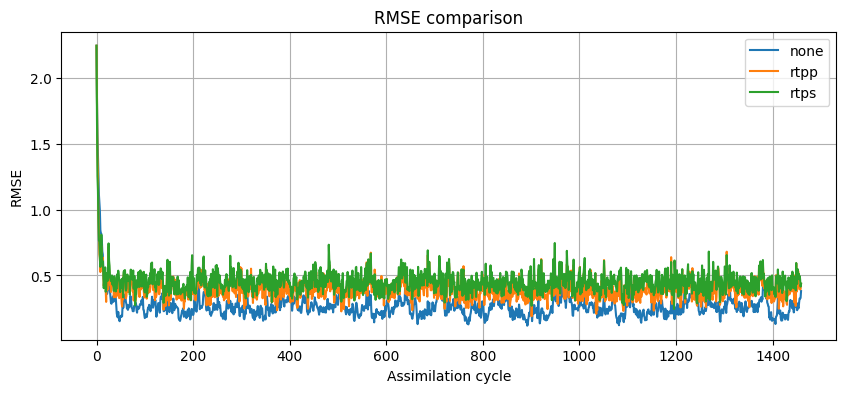

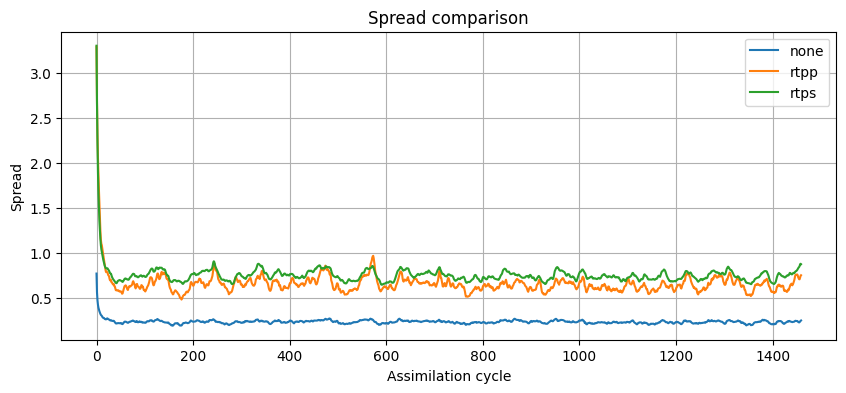

In [10]:
# =====================================================================
# 5. RMSEとSpreadの比較プロット
# =====================================================================
plt.figure(figsize=(10, 4))
for method in results:
    plt.plot(results[method]["rmse"], label=method)
plt.xlabel("Assimilation cycle")
plt.ylabel("RMSE")
plt.title("RMSE comparison")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
for method in results:
    plt.plot(results[method]["spread"], label=method)
plt.xlabel("Assimilation cycle")
plt.ylabel("Spread")
plt.title("Spread comparison")
plt.legend()
plt.grid(True)
plt.show()


## $\alpha$ sensitivity

Number of experiments: 13
Cases:
('none', 0.0)
('rtpp', 0.0)
('rtps', 0.0)
('rtpp', 0.2)
('rtps', 0.2)
('rtpp', 0.4)
('rtps', 0.4)
('rtpp', 0.6)
('rtps', 0.6)
('rtpp', 0.8)
('rtps', 0.8)
('rtpp', 1.0)
('rtps', 1.0)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of  13 | elapsed:   31.9s remaining:  2.9min
[Parallel(n_jobs=-1)]: Done   4 out of  13 | elapsed:   32.1s remaining:  1.2min
[Parallel(n_jobs=-1)]: Done   6 out of  13 | elapsed:   32.2s remaining:   37.6s


All experiments finished. Total elapsed time: 34.94 sec


[Parallel(n_jobs=-1)]: Done   8 out of  13 | elapsed:   34.7s remaining:   21.6s
[Parallel(n_jobs=-1)]: Done  10 out of  13 | elapsed:   34.7s remaining:   10.3s
[Parallel(n_jobs=-1)]: Done  13 out of  13 | elapsed:   34.8s finished


,method,alpha,mean_rmse,mean_spread,spread_rmse_ratio,elapsed_sec
0,none,0.0,0.255790,0.236881,0.926078,31.279411
1,rtpp,0.0,0.255790,0.236881,0.926078,31.474851
2,rtpp,0.2,0.261445,0.273621,1.046570,31.557556
3,rtpp,0.4,0.280888,0.338414,1.204801,31.683043
4,rtpp,0.6,0.332207,0.476294,1.433726,31.530056
5,rtpp,0.8,0.533433,1.207074,2.262840,31.669688
6,rtpp,1.0,2.101123,11.333561,5.394049,31.345160
7,rtps,0.0,0.255790,0.236881,0.926078,34.130409
8,rtps,0.2,0.261962,0.292004,1.114682,34.147135
9,rtps,0.4,0.296855,0.385727,1.299377,34.178589



Baseline: None / LETKF-mult
mean RMSE       = 0.255790
mean spread     = 0.236881
spread/RMSE     = 0.926078


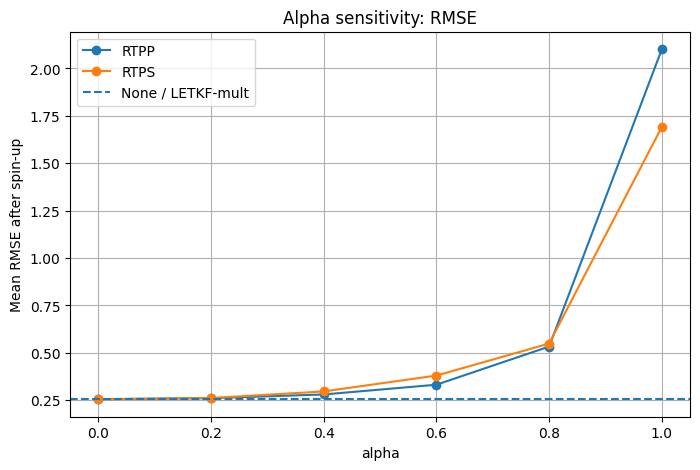

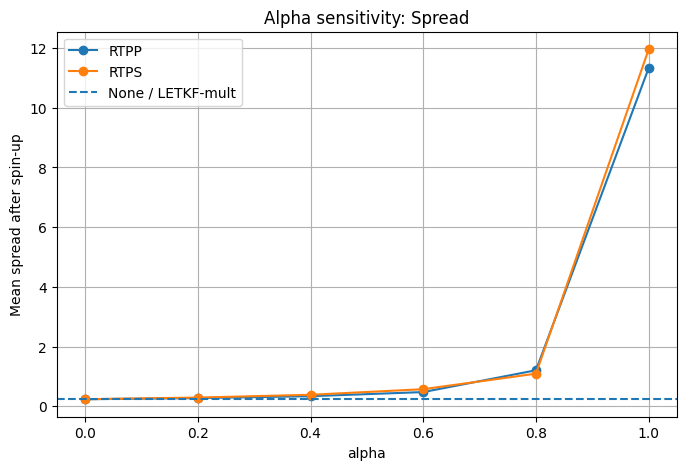

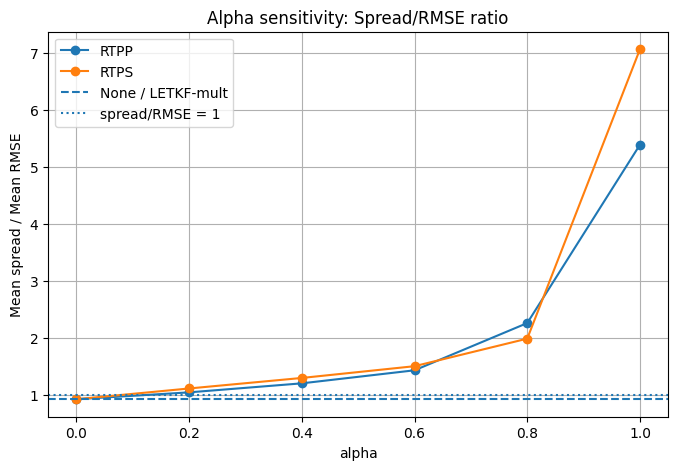


Best alpha for RTPP by mean RMSE: 0.0
Best alpha for RTPS by mean RMSE: 0.0


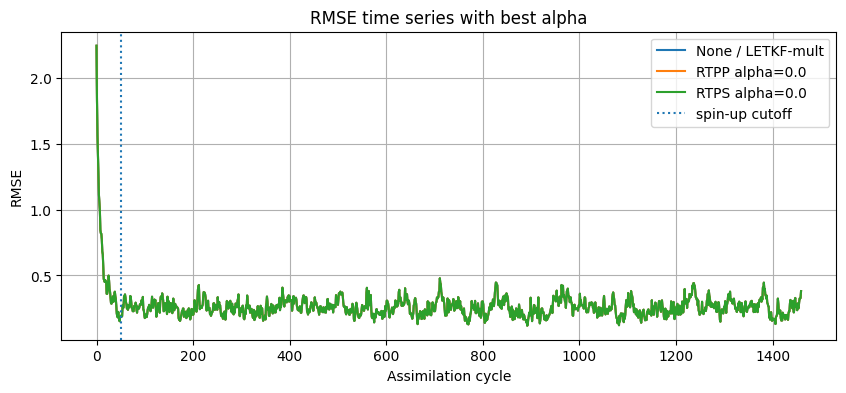

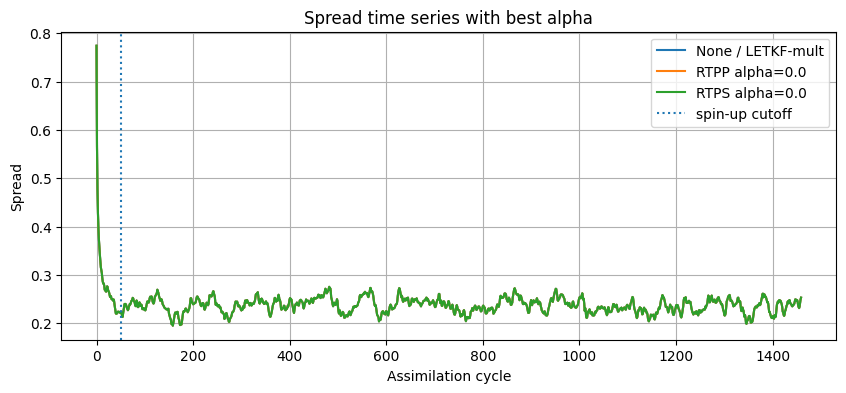


Alpha sensitivity summary
--------------------------------
None / LETKF-mult: RMSE = 0.255790, spread = 0.236881
Best RTPP alpha  : 0.0, RMSE = 0.255790
Best RTPS alpha  : 0.0, RMSE = 0.255790


In [11]:
# =====================================================================
# Fast alpha sensitivity experiment using joblib
# None / RTPP / RTPS 比較
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import time

# ------------------------------------------------------------
# 1. 実験設定
# ------------------------------------------------------------
num_eval_cycles = num_cycles       # まずは短め。全期間で回すなら num_cycles に変更
spinup = 50                 # 平均計算から除外する初期サイクル数

sigma = 3.0                 # 局所化半径
inflation = 1.05            # 乗算的インフレーション Delta
obs_indices = np.arange(N)  # 全点観測

alpha_list = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

seed = 42                   # 全実験で同じ初期アンサンブルにする
n_jobs = -1                 # -1 で全CPUコア使用。重い場合は 2, 4 などに変更

# ------------------------------------------------------------
# 2. 1ケース分の実行関数
# ------------------------------------------------------------
def run_one_alpha_case(method, alpha):
    """
    method: "none", "rtpp", "rtps"
    alpha : RTPP/RTPS の relaxation coefficient
    """
    start = time.time()

    rmse, spread = run_letkf_experiment(
        y_o_data=y_o_data_full[:num_eval_cycles],
        true_states=true_states[:num_eval_cycles],
        obs_indices=obs_indices,
        sigma=sigma,
        inflation=inflation,
        method=method,
        alpha=alpha,
        seed=seed,
    )

    mean_rmse = np.mean(rmse[spinup:])
    mean_spread = np.mean(spread[spinup:])
    spread_rmse_ratio = mean_spread / (mean_rmse + 1.0e-12)

    elapsed = time.time() - start

    return {
        "method": method,
        "alpha": alpha,
        "rmse": rmse,
        "spread": spread,
        "mean_rmse": mean_rmse,
        "mean_spread": mean_spread,
        "spread_rmse_ratio": spread_rmse_ratio,
        "elapsed_sec": elapsed,
    }

# ------------------------------------------------------------
# 3. 実行ケース作成
# ------------------------------------------------------------
cases = []

# None = LETKF-mult は alpha に依存しないので1回だけ
cases.append(("none", 0.0))

# RTPP / RTPS は alpha を振る
for alpha in alpha_list:
    cases.append(("rtpp", float(alpha)))
    cases.append(("rtps", float(alpha)))

print("Number of experiments:", len(cases))
print("Cases:")
for c in cases:
    print(c)

# ------------------------------------------------------------
# 4. joblib で並列実行
# ------------------------------------------------------------
t0 = time.time()

results_list = Parallel(
    n_jobs=n_jobs,
    backend="loky",
    verbose=10
)(
    delayed(run_one_alpha_case)(method, alpha)
    for method, alpha in cases
)

total_elapsed = time.time() - t0
print(f"All experiments finished. Total elapsed time: {total_elapsed:.2f} sec")

# ------------------------------------------------------------
# 5. 結果を整理
# ------------------------------------------------------------
alpha_results = {
    "none": {},
    "rtpp": {},
    "rtps": {},
}

summary = []

for res in results_list:
    method = res["method"]
    alpha = res["alpha"]

    if method == "none":
        alpha_results["none"]["rmse"] = res["rmse"]
        alpha_results["none"]["spread"] = res["spread"]
    else:
        alpha_results[method][alpha] = {
            "rmse": res["rmse"],
            "spread": res["spread"],
        }

    summary.append({
        "method": method,
        "alpha": alpha,
        "mean_rmse": res["mean_rmse"],
        "mean_spread": res["mean_spread"],
        "spread_rmse_ratio": res["spread_rmse_ratio"],
        "elapsed_sec": res["elapsed_sec"],
    })

# 表示用に method, alpha でソート
summary = sorted(summary, key=lambda x: (x["method"], x["alpha"]))

try:
    import pandas as pd
    summary_df = pd.DataFrame(summary)
    display(summary_df)
except Exception:
    for row in summary:
        print(row)

# ------------------------------------------------------------
# 6. None / LETKF-mult の基準値
# ------------------------------------------------------------
none_row = [row for row in summary if row["method"] == "none"][0]

mean_rmse_none = none_row["mean_rmse"]
mean_spread_none = none_row["mean_spread"]
mean_ratio_none = none_row["spread_rmse_ratio"]

rmse_none = alpha_results["none"]["rmse"]
spread_none = alpha_results["none"]["spread"]

print()
print("Baseline: None / LETKF-mult")
print(f"mean RMSE       = {mean_rmse_none:.6f}")
print(f"mean spread     = {mean_spread_none:.6f}")
print(f"spread/RMSE     = {mean_ratio_none:.6f}")

# ------------------------------------------------------------
# 7. alpha ごとの平均RMSE / spread / spread-RMSE比
# ------------------------------------------------------------
rtpp_mean_rmse = np.array([
    np.mean(alpha_results["rtpp"][float(alpha)]["rmse"][spinup:])
    for alpha in alpha_list
])

rtps_mean_rmse = np.array([
    np.mean(alpha_results["rtps"][float(alpha)]["rmse"][spinup:])
    for alpha in alpha_list
])

rtpp_mean_spread = np.array([
    np.mean(alpha_results["rtpp"][float(alpha)]["spread"][spinup:])
    for alpha in alpha_list
])

rtps_mean_spread = np.array([
    np.mean(alpha_results["rtps"][float(alpha)]["spread"][spinup:])
    for alpha in alpha_list
])

rtpp_ratio = rtpp_mean_spread / (rtpp_mean_rmse + 1.0e-12)
rtps_ratio = rtps_mean_spread / (rtps_mean_rmse + 1.0e-12)

# ------------------------------------------------------------
# 8. alpha に対する平均RMSE
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(alpha_list, rtpp_mean_rmse, marker="o", label="RTPP")
plt.plot(alpha_list, rtps_mean_rmse, marker="o", label="RTPS")
plt.axhline(mean_rmse_none, linestyle="--", label="None / LETKF-mult")
plt.xlabel("alpha")
plt.ylabel("Mean RMSE after spin-up")
plt.title("Alpha sensitivity: RMSE")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 9. alpha に対する平均spread
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(alpha_list, rtpp_mean_spread, marker="o", label="RTPP")
plt.plot(alpha_list, rtps_mean_spread, marker="o", label="RTPS")
plt.axhline(mean_spread_none, linestyle="--", label="None / LETKF-mult")
plt.xlabel("alpha")
plt.ylabel("Mean spread after spin-up")
plt.title("Alpha sensitivity: Spread")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 10. alpha に対する spread/RMSE 比
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(alpha_list, rtpp_ratio, marker="o", label="RTPP")
plt.plot(alpha_list, rtps_ratio, marker="o", label="RTPS")
plt.axhline(mean_ratio_none, linestyle="--", label="None / LETKF-mult")
plt.axhline(1.0, linestyle=":", label="spread/RMSE = 1")
plt.xlabel("alpha")
plt.ylabel("Mean spread / Mean RMSE")
plt.title("Alpha sensitivity: Spread/RMSE ratio")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 11. 最良 alpha を選んで時系列比較
# ------------------------------------------------------------
best_alpha_rtpp = float(alpha_list[np.nanargmin(rtpp_mean_rmse)])
best_alpha_rtps = float(alpha_list[np.nanargmin(rtps_mean_rmse)])

print()
print(f"Best alpha for RTPP by mean RMSE: {best_alpha_rtpp}")
print(f"Best alpha for RTPS by mean RMSE: {best_alpha_rtps}")

rmse_rtpp_best = alpha_results["rtpp"][best_alpha_rtpp]["rmse"]
rmse_rtps_best = alpha_results["rtps"][best_alpha_rtps]["rmse"]

spread_rtpp_best = alpha_results["rtpp"][best_alpha_rtpp]["spread"]
spread_rtps_best = alpha_results["rtps"][best_alpha_rtps]["spread"]

plt.figure(figsize=(10, 4))
plt.plot(rmse_none, label="None / LETKF-mult")
plt.plot(rmse_rtpp_best, label=f"RTPP alpha={best_alpha_rtpp}")
plt.plot(rmse_rtps_best, label=f"RTPS alpha={best_alpha_rtps}")
plt.axvline(spinup, linestyle=":", label="spin-up cutoff")
plt.xlabel("Assimilation cycle")
plt.ylabel("RMSE")
plt.title("RMSE time series with best alpha")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(spread_none, label="None / LETKF-mult")
plt.plot(spread_rtpp_best, label=f"RTPP alpha={best_alpha_rtpp}")
plt.plot(spread_rtps_best, label=f"RTPS alpha={best_alpha_rtps}")
plt.axvline(spinup, linestyle=":", label="spin-up cutoff")
plt.xlabel("Assimilation cycle")
plt.ylabel("Spread")
plt.title("Spread time series with best alpha")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 12. 最終確認表示
# ------------------------------------------------------------
print()
print("Alpha sensitivity summary")
print("--------------------------------")
print(f"None / LETKF-mult: RMSE = {mean_rmse_none:.6f}, spread = {mean_spread_none:.6f}")
print(f"Best RTPP alpha  : {best_alpha_rtpp}, RMSE = {np.nanmin(rtpp_mean_rmse):.6f}")
print(f"Best RTPS alpha  : {best_alpha_rtps}, RMSE = {np.nanmin(rtps_mean_rmse):.6f}")

Land indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Ocean indices: [20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
Observation indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Number of observations: 20
Number of experiments: 13
Cases:
('none', 0.0)
('rtpp', 0.0)
('rtps', 0.0)
('rtpp', 0.2)
('rtps', 0.2)
('rtpp', 0.4)
('rtps', 0.4)
('rtpp', 0.6)
('rtps', 0.6)
('rtpp', 0.8)
('rtps', 0.8)
('rtpp', 1.0)
('rtps', 1.0)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of  13 | elapsed:    4.6s remaining:   25.6s
[Parallel(n_jobs=-1)]: Done   4 out of  13 | elapsed:    4.6s remaining:   10.5s
[Parallel(n_jobs=-1)]: Done   6 out of  13 | elapsed:    4.6s remaining:    5.4s


All experiments finished. Total elapsed time: 5.12 sec


[Parallel(n_jobs=-1)]: Done   8 out of  13 | elapsed:    4.9s remaining:    3.0s
[Parallel(n_jobs=-1)]: Done  10 out of  13 | elapsed:    5.0s remaining:    1.4s
[Parallel(n_jobs=-1)]: Done  13 out of  13 | elapsed:    5.0s finished


,method,alpha,mean_rmse_global,mean_rmse_land,mean_rmse_ocean,mean_spread,spread_rmse_ratio,elapsed_sec
0,none,0.0,2.849253,0.410920,4.006209,3.139869,1.101997,4.641426
1,rtpp,0.0,2.849253,0.410920,4.006209,3.139869,1.101997,4.679520
2,rtpp,0.2,2.945292,0.494306,4.130008,3.101008,1.052869,4.690169
3,rtpp,0.4,2.871025,0.393377,4.039293,3.234327,1.126541,4.704811
4,rtpp,0.6,3.106384,0.459605,4.366833,3.315492,1.067316,4.652505
5,rtpp,0.8,3.200245,0.701012,4.467934,3.794163,1.185585,4.676333
6,rtpp,1.0,15.569397,2.624951,21.844771,29.208915,1.876047,4.530015
7,rtps,0.0,2.849253,0.410920,4.006209,3.139869,1.101997,5.067629
8,rtps,0.2,2.751726,0.373552,3.872025,3.001195,1.090659,5.041203
9,rtps,0.4,2.940151,0.405006,4.136492,3.266840,1.111113,5.025925



Baseline: None / LETKF-mult, front 20 observations
Global RMSE = 2.849253
Land RMSE   = 0.410920
Ocean RMSE  = 4.006209
Spread      = 3.139869


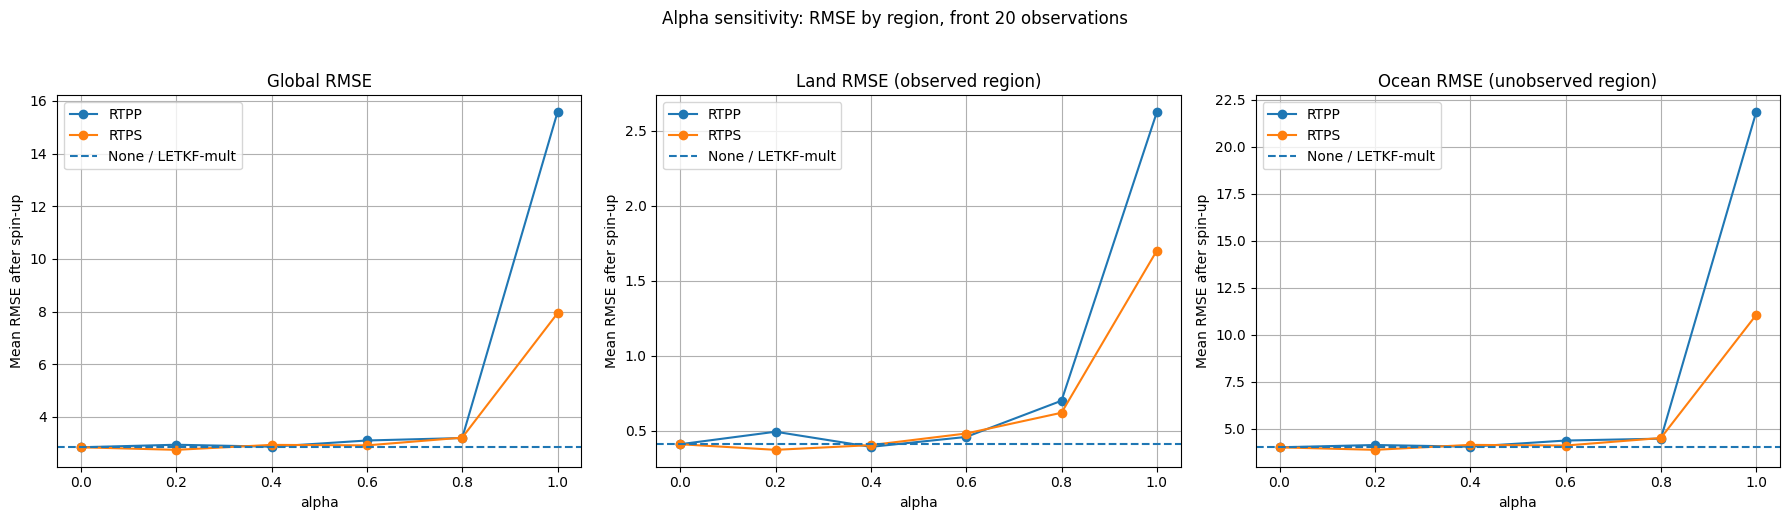


Best alpha for RTPP by Global RMSE: 0.0
Best alpha for RTPS by Global RMSE: 0.2


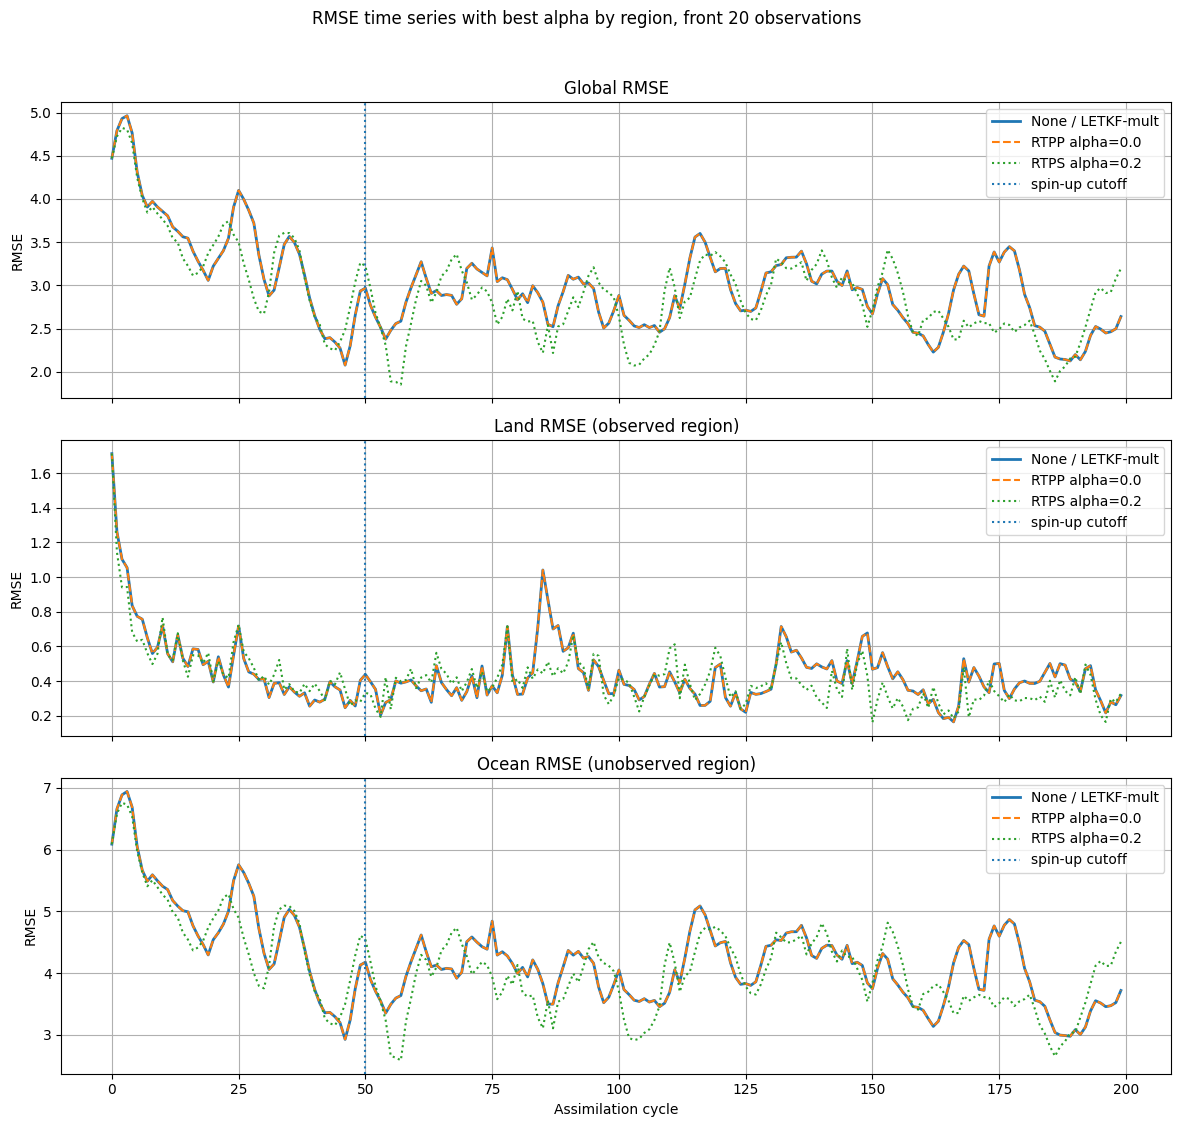

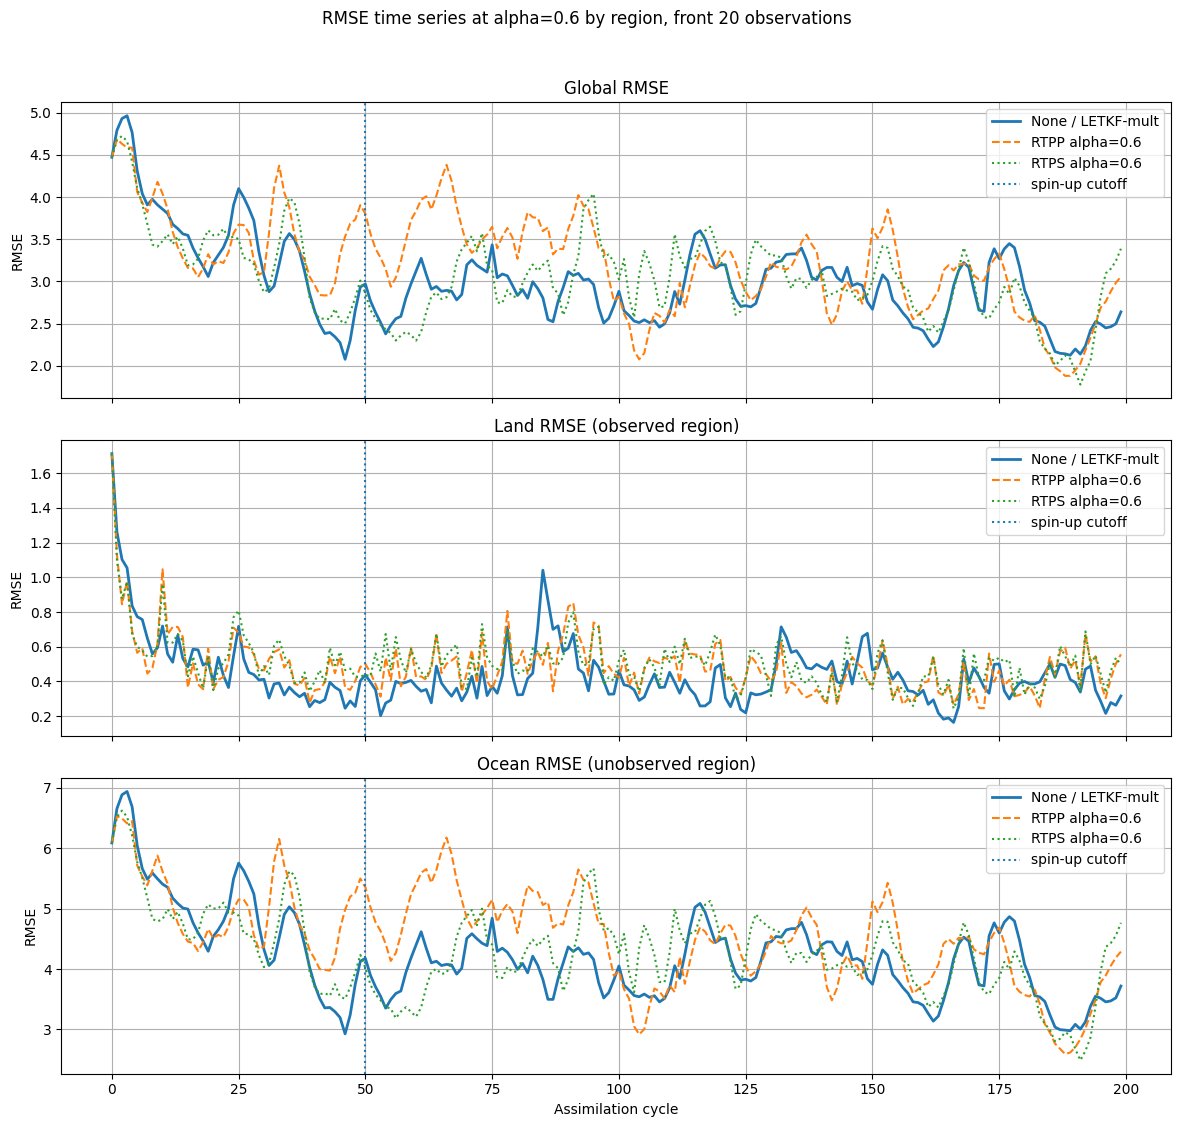


Alpha sensitivity summary: front 20 observations
-----------------------------------------------
None / LETKF-mult Global RMSE = 2.849253
None / LETKF-mult Land RMSE   = 0.410920
None / LETKF-mult Ocean RMSE  = 4.006209
Best RTPP alpha by Global RMSE: 0.0, RMSE = 2.849253
Best RTPS alpha by Global RMSE: 0.2, RMSE = 2.751726


In [12]:
# =====================================================================
# Alpha sensitivity experiment: 前半20点のみ観測 + 地域別RMSE
# Global / Land / Ocean に分けてRMSEを可視化
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import time

# ------------------------------------------------------------
# 1. 実験設定
# ------------------------------------------------------------
num_eval_cycles = 200
spinup = 50

sigma = 3.0
inflation = 1.05

# Land = 前半20点, Ocean = 後半20点 と定義する
land_indices = np.arange(0, 20)
ocean_indices = np.arange(20, N)

# 観測は前半20点のみ
obs_indices_front20 = land_indices.copy()

alpha_list = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

seed = 42
n_jobs = -1

print("Land indices:", land_indices)
print("Ocean indices:", ocean_indices)
print("Observation indices:", obs_indices_front20)
print("Number of observations:", len(obs_indices_front20))

# ------------------------------------------------------------
# 2. 地域別RMSEを記録する実験関数
# ------------------------------------------------------------
def run_letkf_experiment_regional(
    y_o_data,
    true_states,
    obs_indices,
    land_indices,
    ocean_indices,
    sigma=3.0,
    inflation=1.0,
    method="none",
    alpha=0.0,
    seed=42,
):
    """
    LETKF実験を回し、Global / Land / Ocean のRMSEを別々に記録する。

    Land  : 前半20点
    Ocean : 後半20点

    戻り値:
        rmse_dict["global"], rmse_dict["land"], rmse_dict["ocean"]
        spread
    """
    obs_indices = np.asarray(obs_indices, dtype=int)
    land_indices = np.asarray(land_indices, dtype=int)
    ocean_indices = np.asarray(ocean_indices, dtype=int)

    H = make_H(obs_indices, N)
    R = np.eye(len(obs_indices))

    # 観測データを観測点だけに制限
    y_obs = y_o_data[:, obs_indices]

    n_cycles = y_obs.shape[0]

    rmse_global = np.zeros(n_cycles)
    rmse_land = np.zeros(n_cycles)
    rmse_ocean = np.zeros(n_cycles)
    spread = np.zeros(n_cycles)

    # 初期アンサンブル
    rng_enkf = np.random.default_rng(seed=seed)
    init_noise = rng_enkf.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)

    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N - 1)] += 1.001
    X_a = M(x_raw_init[:, None] + init_noise, dt, steps_spin_up)

    for t in range(n_cycles):
        # forecast
        X_b = M(X_a, dt, sampling_interval)

        # analysis
        X_a, xa_mean, dXa = letkf_analysis(
            X_b=X_b,
            y_o=y_obs[t],
            H=H,
            R=R,
            obs_indices=obs_indices,
            sigma=sigma,
            inflation=inflation,
            method=method,
            alpha=alpha,
        )

        err = xa_mean - true_states[t]

        rmse_global[t] = np.sqrt(np.mean(err**2))
        rmse_land[t] = np.sqrt(np.mean(err[land_indices]**2))
        rmse_ocean[t] = np.sqrt(np.mean(err[ocean_indices]**2))

        # spreadは従来通りglobal平均として記録
        spread[t] = np.sqrt(np.mean(np.var(X_a, axis=1, ddof=1)))

    rmse_dict = {
        "global": rmse_global,
        "land": rmse_land,
        "ocean": rmse_ocean,
    }

    return rmse_dict, spread


# ------------------------------------------------------------
# 3. 1ケース分の実行関数
# ------------------------------------------------------------
def run_one_alpha_case_front20_regional(method, alpha):
    start = time.time()

    rmse_dict, spread = run_letkf_experiment_regional(
        y_o_data=y_o_data_full[:num_eval_cycles],
        true_states=true_states[:num_eval_cycles],
        obs_indices=obs_indices_front20,
        land_indices=land_indices,
        ocean_indices=ocean_indices,
        sigma=sigma,
        inflation=inflation,
        method=method,
        alpha=alpha,
        seed=seed,
    )

    mean_rmse_global = np.nanmean(rmse_dict["global"][spinup:])
    mean_rmse_land = np.nanmean(rmse_dict["land"][spinup:])
    mean_rmse_ocean = np.nanmean(rmse_dict["ocean"][spinup:])

    mean_spread = np.nanmean(spread[spinup:])
    spread_rmse_ratio = mean_spread / (mean_rmse_global + 1.0e-12)

    elapsed = time.time() - start

    return {
        "method": method,
        "alpha": alpha,
        "rmse": rmse_dict,
        "spread": spread,
        "mean_rmse_global": mean_rmse_global,
        "mean_rmse_land": mean_rmse_land,
        "mean_rmse_ocean": mean_rmse_ocean,
        "mean_spread": mean_spread,
        "spread_rmse_ratio": spread_rmse_ratio,
        "elapsed_sec": elapsed,
    }


# ------------------------------------------------------------
# 4. 実行ケース作成
# ------------------------------------------------------------
cases_front20 = []

# None = LETKF-mult は alpha に依存しないので1回だけ
cases_front20.append(("none", 0.0))

# RTPP / RTPS は alpha を振る
for alpha in alpha_list:
    cases_front20.append(("rtpp", float(alpha)))
    cases_front20.append(("rtps", float(alpha)))

print("Number of experiments:", len(cases_front20))
print("Cases:")
for case in cases_front20:
    print(case)


# ------------------------------------------------------------
# 5. joblibで並列実行
# ------------------------------------------------------------
t0 = time.time()

results_list_front20 = Parallel(
    n_jobs=n_jobs,
    backend="loky",
    verbose=10
)(
    delayed(run_one_alpha_case_front20_regional)(method, alpha)
    for method, alpha in cases_front20
)

total_elapsed = time.time() - t0
print(f"All experiments finished. Total elapsed time: {total_elapsed:.2f} sec")


# ------------------------------------------------------------
# 6. 結果整理
# ------------------------------------------------------------
alpha_results_front20 = {
    "none": {},
    "rtpp": {},
    "rtps": {},
}

summary_front20 = []

for res in results_list_front20:
    method = res["method"]
    alpha = res["alpha"]

    if method == "none":
        alpha_results_front20["none"]["rmse"] = res["rmse"]
        alpha_results_front20["none"]["spread"] = res["spread"]
    else:
        alpha_results_front20[method][alpha] = {
            "rmse": res["rmse"],
            "spread": res["spread"],
        }

    summary_front20.append({
        "method": method,
        "alpha": alpha,
        "mean_rmse_global": res["mean_rmse_global"],
        "mean_rmse_land": res["mean_rmse_land"],
        "mean_rmse_ocean": res["mean_rmse_ocean"],
        "mean_spread": res["mean_spread"],
        "spread_rmse_ratio": res["spread_rmse_ratio"],
        "elapsed_sec": res["elapsed_sec"],
    })

summary_front20 = sorted(summary_front20, key=lambda x: (x["method"], x["alpha"]))

try:
    import pandas as pd
    summary_front20_df = pd.DataFrame(summary_front20)
    display(summary_front20_df)
except Exception:
    for row in summary_front20:
        print(row)


# ------------------------------------------------------------
# 7. 平均RMSE配列を作る
# ------------------------------------------------------------
def mean_rmse_by_region(method, region):
    return np.array([
        np.nanmean(alpha_results_front20[method][float(alpha)]["rmse"][region][spinup:])
        for alpha in alpha_list
    ])

rtpp_mean_rmse_global = mean_rmse_by_region("rtpp", "global")
rtpp_mean_rmse_land = mean_rmse_by_region("rtpp", "land")
rtpp_mean_rmse_ocean = mean_rmse_by_region("rtpp", "ocean")

rtps_mean_rmse_global = mean_rmse_by_region("rtps", "global")
rtps_mean_rmse_land = mean_rmse_by_region("rtps", "land")
rtps_mean_rmse_ocean = mean_rmse_by_region("rtps", "ocean")

rmse_none_global = alpha_results_front20["none"]["rmse"]["global"]
rmse_none_land = alpha_results_front20["none"]["rmse"]["land"]
rmse_none_ocean = alpha_results_front20["none"]["rmse"]["ocean"]

mean_rmse_none_global = np.nanmean(rmse_none_global[spinup:])
mean_rmse_none_land = np.nanmean(rmse_none_land[spinup:])
mean_rmse_none_ocean = np.nanmean(rmse_none_ocean[spinup:])

spread_none_front20 = alpha_results_front20["none"]["spread"]
mean_spread_none_front20 = np.nanmean(spread_none_front20[spinup:])

print()
print("Baseline: None / LETKF-mult, front 20 observations")
print(f"Global RMSE = {mean_rmse_none_global:.6f}")
print(f"Land RMSE   = {mean_rmse_none_land:.6f}")
print(f"Ocean RMSE  = {mean_rmse_none_ocean:.6f}")
print(f"Spread      = {mean_spread_none_front20:.6f}")


# ------------------------------------------------------------
# 8. Alpha感度RMSEを Global / Land / Ocean に分けて可視化
# ------------------------------------------------------------
def plot_alpha_rmse_by_region():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    plot_specs = [
        {
            "region": "global",
            "title": "Global RMSE",
            "none": mean_rmse_none_global,
            "rtpp": rtpp_mean_rmse_global,
            "rtps": rtps_mean_rmse_global,
        },
        {
            "region": "land",
            "title": "Land RMSE (observed region)",
            "none": mean_rmse_none_land,
            "rtpp": rtpp_mean_rmse_land,
            "rtps": rtps_mean_rmse_land,
        },
        {
            "region": "ocean",
            "title": "Ocean RMSE (unobserved region)",
            "none": mean_rmse_none_ocean,
            "rtpp": rtpp_mean_rmse_ocean,
            "rtps": rtps_mean_rmse_ocean,
        },
    ]

    for ax, spec in zip(axes, plot_specs):
        ax.plot(alpha_list, spec["rtpp"], marker="o", label="RTPP")
        ax.plot(alpha_list, spec["rtps"], marker="o", label="RTPS")
        ax.axhline(spec["none"], linestyle="--", label="None / LETKF-mult")

        ax.set_title(spec["title"])
        ax.set_xlabel("alpha")
        ax.set_ylabel("Mean RMSE after spin-up")
        ax.grid(True)
        ax.legend()

    fig.suptitle("Alpha sensitivity: RMSE by region, front 20 observations", y=1.03)
    plt.tight_layout()
    plt.show()

plot_alpha_rmse_by_region()


# ------------------------------------------------------------
# 9. Global RMSE基準で最良alphaを選ぶ
# ------------------------------------------------------------
best_alpha_rtpp_front20 = float(alpha_list[np.nanargmin(rtpp_mean_rmse_global)])
best_alpha_rtps_front20 = float(alpha_list[np.nanargmin(rtps_mean_rmse_global)])

print()
print(f"Best alpha for RTPP by Global RMSE: {best_alpha_rtpp_front20}")
print(f"Best alpha for RTPS by Global RMSE: {best_alpha_rtps_front20}")


# ------------------------------------------------------------
# 10. 最良alphaのRMSE時系列を Global / Land / Ocean に分けて可視化
# ------------------------------------------------------------
def plot_rmse_timeseries_by_region(alpha_rtpp, alpha_rtps):
    fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

    region_specs = [
        ("global", "Global RMSE"),
        ("land", "Land RMSE (observed region)"),
        ("ocean", "Ocean RMSE (unobserved region)"),
    ]

    for ax, (region, title) in zip(axes, region_specs):
        ax.plot(
            alpha_results_front20["none"]["rmse"][region],
            label="None / LETKF-mult",
            linewidth=2,
        )
        ax.plot(
            alpha_results_front20["rtpp"][alpha_rtpp]["rmse"][region],
            label=f"RTPP alpha={alpha_rtpp}",
            linestyle="--",
        )
        ax.plot(
            alpha_results_front20["rtps"][alpha_rtps]["rmse"][region],
            label=f"RTPS alpha={alpha_rtps}",
            linestyle=":",
        )

        ax.axvline(spinup, linestyle=":", label="spin-up cutoff")
        ax.set_title(title)
        ax.set_ylabel("RMSE")
        ax.grid(True)
        ax.legend()

    axes[-1].set_xlabel("Assimilation cycle")

    fig.suptitle("RMSE time series with best alpha by region, front 20 observations", y=1.02)
    plt.tight_layout()
    plt.show()

plot_rmse_timeseries_by_region(best_alpha_rtpp_front20, best_alpha_rtps_front20)


# ------------------------------------------------------------
# 11. 非ゼロalphaを指定してRMSE時系列を Global / Land / Ocean に分けて可視化
# ------------------------------------------------------------
alpha_show = 0.6

def plot_rmse_timeseries_fixed_alpha(alpha_show):
    fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

    region_specs = [
        ("global", "Global RMSE"),
        ("land", "Land RMSE (observed region)"),
        ("ocean", "Ocean RMSE (unobserved region)"),
    ]

    for ax, (region, title) in zip(axes, region_specs):
        ax.plot(
            alpha_results_front20["none"]["rmse"][region],
            label="None / LETKF-mult",
            linewidth=2,
        )
        ax.plot(
            alpha_results_front20["rtpp"][alpha_show]["rmse"][region],
            label=f"RTPP alpha={alpha_show}",
            linestyle="--",
        )
        ax.plot(
            alpha_results_front20["rtps"][alpha_show]["rmse"][region],
            label=f"RTPS alpha={alpha_show}",
            linestyle=":",
        )

        ax.axvline(spinup, linestyle=":", label="spin-up cutoff")
        ax.set_title(title)
        ax.set_ylabel("RMSE")
        ax.grid(True)
        ax.legend()

    axes[-1].set_xlabel("Assimilation cycle")

    fig.suptitle(f"RMSE time series at alpha={alpha_show} by region, front 20 observations", y=1.02)
    plt.tight_layout()
    plt.show()

plot_rmse_timeseries_fixed_alpha(alpha_show)


# ------------------------------------------------------------
# 12. 最終表示
# ------------------------------------------------------------
print()
print("Alpha sensitivity summary: front 20 observations")
print("-----------------------------------------------")
print(f"None / LETKF-mult Global RMSE = {mean_rmse_none_global:.6f}")
print(f"None / LETKF-mult Land RMSE   = {mean_rmse_none_land:.6f}")
print(f"None / LETKF-mult Ocean RMSE  = {mean_rmse_none_ocean:.6f}")
print(f"Best RTPP alpha by Global RMSE: {best_alpha_rtpp_front20}, RMSE = {np.nanmin(rtpp_mean_rmse_global):.6f}")
print(f"Best RTPS alpha by Global RMSE: {best_alpha_rtps_front20}, RMSE = {np.nanmin(rtps_mean_rmse_global):.6f}")